# 04 — Allocation Backtest

This notebook compares transparent allocation policies in a walk-forward setting.

The objective is not to claim that the model produces alpha. The objective is to test whether regime-aware risk-budget control improves risk diagnostics relative to robust constant-risk baselines.

Compared policies:

1. equal weight,
2. inverse volatility,
3. minimum variance,
4. regime-aware inverse volatility,
5. regime-aware minimum variance.

## Research objective

Evaluate whether a regime-aware risk-budget overlay improves portfolio risk control.

The notebook should answer:

- Are the regime labels loaded correctly?
- Are all expected regimes present before backtesting?
- Are strategies actually rebalancing?
- Does regime awareness reduce volatility, CVaR, or drawdown?
- Is any improvement driven by robust risk control rather than an alpha claim?
- Does the regime-aware policy behave as designed, by reducing risk budget in higher-stress regimes?

## Expected local outputs

Core outputs:

- `data/processed/backtest_strategy_returns.csv`
- `data/processed/backtest_performance_summary.csv`
- `data/processed/backtest_weights_long.csv`

Diagnostic outputs:

- `data/processed/allocation_regime_audit.csv`
- `data/processed/allocation_strategy_audit.csv`
- `data/processed/allocation_risk_reduction.csv`
- `data/processed/allocation_average_weights_by_strategy.csv`
- `data/processed/allocation_average_weights_by_regime.csv`
- `data/processed/allocation_backtest_manifest.csv`

Figures:

- `reports/figures/04_cumulative_wealth.png`
- `reports/figures/04_drawdowns.png`
- `reports/figures/04_strategy_risk_summary.png`
- `reports/figures/04_regime_budget_series.png`
- `reports/figures/04_regime_aware_weights.png`

Interpretation rule:

> A backtest comparison is useful only if regime labels are valid, rebalancing is working, and the interpretation emphasizes risk control rather than alpha.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
from regime_portfolio.allocation import (
    equal_weight,
    inverse_volatility_weight,
    make_regime_weight_function,
    minimum_variance_weight,
    regime_risk_budget,
)
from regime_portfolio.backtest import run_backtest
from regime_portfolio.metrics import compare_strategies
from regime_portfolio.risk import drawdown_series

## 0. Upstream artifact check

This notebook depends on processed files created by earlier notebooks.

Required upstream files:

- `data/processed/returns.csv`
- `data/processed/regime_labels.csv`

If this check fails, rerun:

1. `01_data_pipeline.ipynb`
2. `02_regime_detection.ipynb`
3. `03_regime_conditioned_risk.ipynb`

In [3]:
required_files = [
    DATA_DIR / "returns.csv",
    DATA_DIR / "regime_labels.csv",
]

missing_files = [path for path in required_files if not path.exists()]

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

if missing_files:
    print("Missing required files:")
    for path in missing_files:
        print("-", path)

    raise FileNotFoundError(
        "Missing upstream processed files. "
        "Rerun 01_data_pipeline.ipynb and 02_regime_detection.ipynb from top to bottom."
    )

print("All required upstream files are available.")

Project root: /workspaces/regime-aware-portfolio-risk-allocation
Data directory: /workspaces/regime-aware-portfolio-risk-allocation/data/processed
All required upstream files are available.


In [4]:
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True)
regimes = pd.read_csv(DATA_DIR / "regime_labels.csv", index_col=0, parse_dates=True)["regime"]

aligned = returns.join(regimes.rename("regime"), how="inner").dropna()

returns_aligned = aligned[returns.columns]
regimes_aligned = aligned["regime"].astype(int)

expected_regimes = pd.Index([0, 1, 2], name="regime")
observed_regimes = pd.Index(sorted(regimes_aligned.unique()), name="regime")
missing_regimes = expected_regimes.difference(observed_regimes)

regime_counts = regimes_aligned.value_counts().sort_index().rename("n_obs")
regime_shares = (regime_counts / regime_counts.sum()).rename("sample_share")

MIN_OBS_PER_REGIME = 252
MIN_SHARE_PER_REGIME = 0.05

allocation_regime_audit = pd.Series(
    {
        "returns_rows": len(returns),
        "regime_label_rows": len(regimes),
        "aligned_rows": len(aligned),
        "n_assets": returns_aligned.shape[1],
        "n_observed_regimes": regimes_aligned.nunique(),
        "observed_regimes": ", ".join(map(str, observed_regimes.tolist())),
        "missing_expected_regimes": ", ".join(map(str, missing_regimes.tolist()))
        if len(missing_regimes) > 0
        else "none",
        "min_regime_obs": int(regime_counts.min()),
        "min_regime_share": float(regime_shares.min()),
        "min_required_obs_per_regime": MIN_OBS_PER_REGIME,
        "min_required_share_per_regime": MIN_SHARE_PER_REGIME,
        "passes_regime_count_check": regimes_aligned.nunique() >= 3,
        "passes_min_obs_check": bool((regime_counts >= MIN_OBS_PER_REGIME).all()),
        "passes_min_share_check": bool((regime_shares >= MIN_SHARE_PER_REGIME).all()),
    },
    name="value",
)

allocation_regime_reliability = pd.concat([regime_counts, regime_shares], axis=1)
allocation_regime_reliability["passes_min_obs_check"] = (
    allocation_regime_reliability["n_obs"] >= MIN_OBS_PER_REGIME
)
allocation_regime_reliability["passes_min_share_check"] = (
    allocation_regime_reliability["sample_share"] >= MIN_SHARE_PER_REGIME
)

print("Allocation regime audit")
display(allocation_regime_audit.to_frame())

print("Regime sample reliability")
display(allocation_regime_reliability)

if (
    not bool(allocation_regime_audit.loc["passes_regime_count_check"])
    or not bool(allocation_regime_audit.loc["passes_min_obs_check"])
    or not bool(allocation_regime_audit.loc["passes_min_share_check"])
):
    raise RuntimeError(
        "Allocation regime audit failed. Do not interpret the allocation backtest. "
        "Rerun notebook 02 from top to bottom and check regime_labels.csv."
    )

print("Allocation regime audit passed.")

Allocation regime audit


,value
returns_rows,4852
regime_label_rows,4790
aligned_rows,4790
n_assets,7
n_observed_regimes,3
observed_regimes,"0, 1, 2"
missing_expected_regimes,none
min_regime_obs,520
min_regime_share,0.1086
min_required_obs_per_regime,252


Regime sample reliability


,n_obs,sample_share,passes_min_obs_check,passes_min_share_check
regime,,,,
0,2730,0.5699,True,True
1,1540,0.3215,True,True
2,520,0.1086,True,True


Allocation regime audit passed.


## 2. Backtest design

The walk-forward backtest follows conservative conventions:

- weights are estimated from past data only,
- weights are updated monthly,
- the lookback window is one trading year,
- transaction costs are deducted using one-way turnover,
- no leverage is introduced in this first version.

This is a research diagnostic, not a production simulation.

In [5]:
LOOKBACK = 252
REBALANCE_FREQUENCY = "ME"
TRANSACTION_COST_BPS = 2.0

risk_budgets = {
    0: 1.00,
    1: 0.70,
    2: 0.35,
}

risk_budget_table = pd.DataFrame(
    {
        "regime": list(risk_budgets.keys()),
        "regime_name": ["low_stress", "intermediate_stress", "high_stress"],
        "risk_budget": list(risk_budgets.values()),
        "n_obs": [int(regime_counts.loc[i]) for i in risk_budgets],
        "sample_share": [float(regime_shares.loc[i]) for i in risk_budgets],
    }
)

print("Backtest configuration")
display(
    pd.Series(
        {
            "lookback_days": LOOKBACK,
            "rebalance_frequency": REBALANCE_FREQUENCY,
            "transaction_cost_bps": TRANSACTION_COST_BPS,
        },
        name="value",
    ).to_frame()
)

print("Risk budgets by ordered regime")
display(risk_budget_table)

Backtest configuration


,value
lookback_days,252
rebalance_frequency,ME
transaction_cost_bps,2.0000


Risk budgets by ordered regime


,regime,regime_name,risk_budget,n_obs,sample_share
0,0,low_stress,1.0000,2730,0.5699
1,1,intermediate_stress,0.7000,1540,0.3215
2,2,high_stress,0.3500,520,0.1086


## 2.1 Allocation sanity check

Before running the full backtest, we inspect one recent lookback window.

This checks whether the allocation functions produce distinct weights:

- equal weight should be uniform,
- inverse volatility should overweight lower-volatility assets,
- minimum variance should differ from equal weight unless the optimizer falls back.

If minimum variance is identical to equal weight, the backtest should not be interpreted until the cause is understood.

In [ ]:
diagnostic_history = returns_aligned.iloc[-LOOKBACK:].copy()

allocation_sanity = pd.concat(
    {
        "equal_weight": equal_weight(diagnostic_history.columns),
        "inverse_volatility": inverse_volatility_weight(diagnostic_history),
        "minimum_variance": minimum_variance_weight(diagnostic_history),
    },
    axis=1,
)

allocation_sanity.loc["sum"] = allocation_sanity.sum()

distance_to_equal = (
    allocation_sanity.drop(index="sum")
    .subtract(allocation_sanity.drop(index="sum")["equal_weight"], axis=0)
    .abs()
    .sum()
    .rename("l1_distance_to_equal_weight")
)

print("Allocation sanity check on the most recent lookback window")
display(allocation_sanity)

print("Distance from equal weight")
display(distance_to_equal.to_frame())

MINVAR_DISTANCE_TOL = 1e-4

if distance_to_equal.loc["minimum_variance"] < MINVAR_DISTANCE_TOL:
    raise RuntimeError(
        "minimum_variance is numerically indistinguishable from equal_weight "
        "on this diagnostic window. Fix src/regime_portfolio/allocation.py "
        "before interpreting the allocation backtest."
    )

print("Minimum-variance sanity check passed.")

Allocation sanity check on the most recent lookback window


,equal_weight,inverse_volatility,minimum_variance
DBC,0.1429,0.0377,0.1429
GLD,0.1429,0.0258,0.1429
IEF,0.1429,0.1511,0.1429
SHY,0.1429,0.5363,0.1429
SPY,0.1429,0.0580,0.1429
TLT,0.1429,0.0737,0.1429
UUP,0.1429,0.1175,0.1429
sum,1.0000,1.0000,1.0000


Distance from equal weight


,l1_distance_to_equal_weight
equal_weight,0.0000
inverse_volatility,0.8033
minimum_variance,0.0000


## 3. Define allocation policies through `src/regime_portfolio`

The allocation rules are deliberately simple and transparent.

The regime-aware policy does not change the optimizer itself. It changes the risk budget:

```text
low stress      -> mostly invested
medium stress   -> partially de-risked
high stress     -> strongly de-risked into SHY

In [ ]:
strategies = {
    "equal_weight": lambda history, current_regime=None: equal_weight(history.columns),
    "inverse_volatility": make_regime_weight_function(
        method="inverse_volatility",
        defensive_asset="SHY",
    ),
    "minimum_variance": make_regime_weight_function(
        method="minimum_variance",
        defensive_asset="SHY",
    ),
    "regime_aware_equal_weight": make_regime_weight_function(
        method="equal_weight",
        defensive_asset="SHY",
        budgets=risk_budgets,
    ),
    "regime_aware_inverse_vol": make_regime_weight_function(
        method="inverse_volatility",
        defensive_asset="SHY",
        budgets=risk_budgets,
    ),
    "regime_aware_min_var": make_regime_weight_function(
        method="minimum_variance",
        defensive_asset="SHY",
        budgets=risk_budgets,
    ),
}

regime_aware_strategy_names = {
    "regime_aware_equal_weight",
    "regime_aware_inverse_vol",
    "regime_aware_min_var",
}

strategy_display_names = {
    "equal_weight": "Equal weight",
    "inverse_volatility": "Inverse volatility",
    "minimum_variance": "Minimum variance",
    "regime_aware_equal_weight": "Regime-aware equal weight",
    "regime_aware_inverse_vol": "Regime-aware inverse vol",
    "regime_aware_min_var": "Regime-aware min var",
}

strategy_order = list(strategies)

display(pd.Series(strategy_order, name="strategy_name").to_frame())

,strategy_name
0,equal_weight
1,inverse_volatility
2,minimum_variance
3,regime_aware_inverse_vol
4,regime_aware_min_var


## 4. Run walk-forward backtests

Only the regime-aware strategy receives the regime state. The other baselines are intentionally regime-blind.

In [8]:
results = {}

for name, strategy_fn in strategies.items():
    use_regimes = regimes_aligned if name in regime_aware_strategy_names else None

    results[name] = run_backtest(
        returns=returns_aligned,
        strategy_fn=strategy_fn,
        regimes=use_regimes,
        lookback=LOOKBACK,
        rebalance_frequency=REBALANCE_FREQUENCY,
        transaction_cost_bps=TRANSACTION_COST_BPS,
    )

strategy_returns = pd.concat(
    {name: result.returns for name, result in results.items()},
    axis=1,
)

strategy_returns.columns = list(results.keys())

print("Strategy returns tail")
display(strategy_returns.tail())

Strategy returns tail


,equal_weight,inverse_volatility,minimum_variance,regime_aware_inverse_vol,regime_aware_min_var
Date,,,,,
2026-06-08,0.0011,0.0003,0.0011,0.0003,0.0011
2026-06-09,-0.0035,-0.0001,-0.0035,-0.0001,-0.0035
2026-06-10,-0.0082,-0.0022,-0.0082,-0.0022,-0.0082
2026-06-11,0.0078,0.0040,0.0078,0.0040,0.0078
2026-06-12,-0.0017,-0.0011,-0.0017,-0.0011,-0.0017


## 4.1 Strategy audit

Before interpreting performance, we check whether the strategies actually behave differently.

The audit reports:

- average daily turnover,
- number of days with nonzero weight changes,
- terminal wealth,
- maximum absolute return difference versus equal weight,
- average exposure to the defensive proxy `SHY`.

This prevents a false comparison where two strategies are numerically identical.

In [ ]:
wealth = np.exp(strategy_returns.fillna(0.0).cumsum())

strategy_audit_rows = []

for name, result in results.items():
    weight_changes = result.weights.diff().abs().sum(axis=1)
    nonzero_weight_change_days = int((weight_changes > 1e-10).sum())

    strategy_audit_rows.append(
        {
            "strategy": name,
            "terminal_wealth": float(wealth[name].iloc[-1]),
            "avg_daily_turnover": float(result.turnover.mean()),
            "total_turnover": float(result.turnover.sum()),
            "nonzero_weight_change_days": nonzero_weight_change_days,
            "avg_SHY_weight": float(result.weights["SHY"].mean())
            if "SHY" in result.weights.columns
            else np.nan,
            "max_abs_return_diff_vs_equal_weight": float(
                (strategy_returns[name] - strategy_returns["equal_weight"]).abs().max()
            ),
        }
    )

allocation_strategy_audit = (
    pd.DataFrame(strategy_audit_rows)
    .sort_values("strategy")
    .reset_index(drop=True)
)

print("Allocation strategy audit")
display(allocation_strategy_audit)

return_distance_matrix = pd.DataFrame(
    index=strategy_returns.columns,
    columns=strategy_returns.columns,
    dtype=float,
)

for i in strategy_returns.columns:
    for j in strategy_returns.columns:
        return_distance_matrix.loc[i, j] = (
            strategy_returns[i] - strategy_returns[j]
        ).abs().max()

print("Maximum absolute daily return difference between strategies")
display(return_distance_matrix)

MINVAR_DISTANCE_TOL = 1e-4

if return_distance_matrix.loc["equal_weight", "minimum_variance"] < 1e-8:
    raise RuntimeError(
        "equal_weight and minimum_variance returns are identical. "
        "The minimum-variance baseline is not valid. "
        "Fix the allocation optimizer before interpreting the backtest."
    )

print("Strategy audit passed: minimum_variance is distinct from equal_weight.")

Allocation strategy audit


,strategy,terminal_wealth,avg_daily_turnover,total_turnover,nonzero_weight_change_days,avg_SHY_weight,max_abs_return_diff_vs_equal_weight
0,equal_weight,2.3163,0.0000,0.0000,0,0.1429,0.0000
1,inverse_volatility,1.7476,0.0005,2.6168,217,0.5887,0.0172
2,minimum_variance,2.3163,0.0000,0.0000,0,0.1429,0.0000
3,regime_aware_inverse_vol,1.7203,0.0016,7.4672,217,0.6511,0.0225
4,regime_aware_min_var,2.1475,0.0024,11.6571,43,0.2703,0.0168


Maximum absolute daily return difference between strategies


,equal_weight,inverse_volatility,minimum_variance,regime_aware_inverse_vol,regime_aware_min_var
equal_weight,0.0000,0.0172,0.0000,0.0225,0.0168
inverse_volatility,0.0172,0.0000,0.0172,0.0068,0.0160
minimum_variance,0.0000,0.0172,0.0000,0.0225,0.0168
regime_aware_inverse_vol,0.0225,0.0068,0.0225,0.0000,0.0160
regime_aware_min_var,0.0168,0.0160,0.0168,0.0160,0.0000


## 5. Compare performance and risk diagnostics

The summary table includes return metrics, but the interpretation should emphasize risk control:

- maximum drawdown,
- CVaR,
- volatility,
- turnover,
- robustness across regimes.

A higher Sharpe ratio is useful only if it is accompanied by plausible risk behavior and not driven by overfitting.

In [ ]:
performance_summary = compare_strategies(strategy_returns)

avg_turnover = pd.Series(
    {name: result.turnover.mean() for name, result in results.items()},
    name="avg_daily_turnover",
)

performance_summary = performance_summary.join(avg_turnover)

baseline = performance_summary.loc["equal_weight"]

risk_reduction = pd.DataFrame(index=performance_summary.index)
risk_reduction["ann_vol_reduction_vs_equal_weight"] = (
    baseline["ann_vol"] - performance_summary["ann_vol"]
)
risk_reduction["max_drawdown_reduction_vs_equal_weight"] = (
    abs(baseline["max_drawdown"]) - performance_summary["max_drawdown"].abs()
)
risk_reduction["cvar_reduction_vs_equal_weight"] = (
    baseline["cvar_5pct"] - performance_summary["cvar_5pct"]
)

performance_summary = performance_summary.join(risk_reduction)
performance_summary = performance_summary.reindex(strategy_order)

display(performance_summary)

,ann_return,ann_vol,sharpe_0rf,sortino_0rf,max_drawdown,calmar,cvar_5pct,skew,kurtosis,avg_daily_turnover,ann_vol_reduction_vs_equal_weight,max_drawdown_reduction_vs_equal_weight,cvar_reduction_vs_equal_weight
regime_aware_inverse_vol,0.0285,0.0248,1.1491,1.9174,-0.0634,0.4500,0.0036,-0.0399,4.9058,0.0016,0.0329,0.0791,0.0049
inverse_volatility,0.0294,0.0276,1.0635,1.7680,-0.0679,0.4323,0.0041,-0.0362,4.3552,0.0005,0.0302,0.0746,0.0045
regime_aware_min_var,0.0402,0.0468,0.8595,1.3860,-0.0995,0.4042,0.0069,-0.4033,3.2445,0.0024,0.0110,0.0431,0.0016
equal_weight,0.0442,0.0578,0.7648,1.2229,-0.1425,0.3100,0.0085,-0.3473,4.7219,0.0000,0.0000,0.0000,0.0000
minimum_variance,0.0442,0.0578,0.7648,1.2229,-0.1425,0.3100,0.0085,-0.3473,4.7219,0.0000,0.0000,0.0000,0.0000


## 6. Visual diagnostic — cumulative wealth

This plot compares cumulative wealth across strategies.

It should be read together with drawdown and CVaR diagnostics. A smoother path with lower drawdown may be more relevant to the project than the highest terminal wealth.

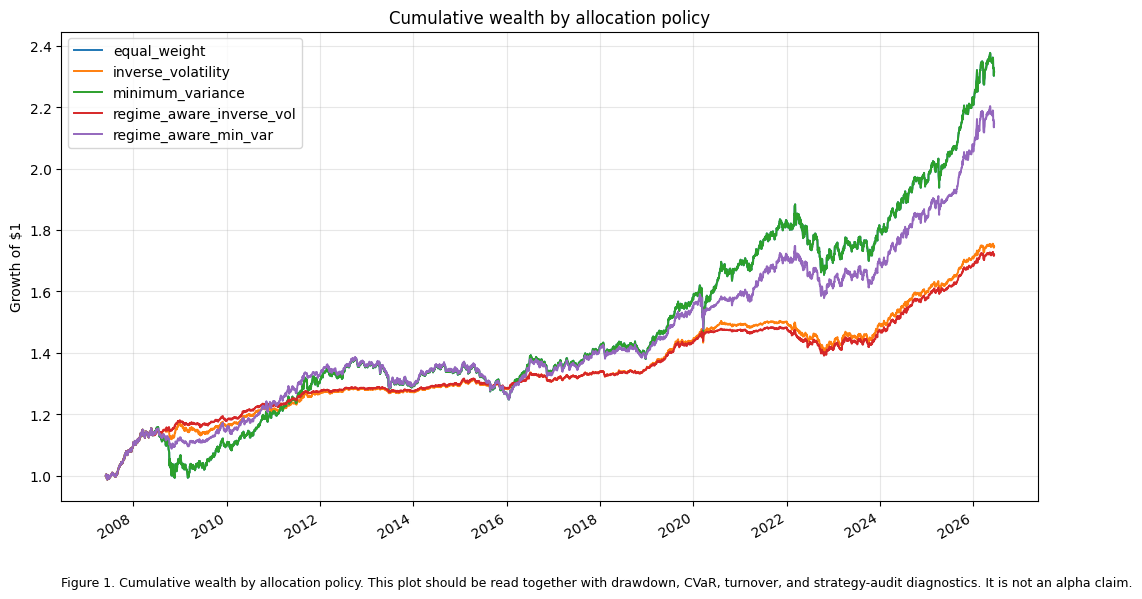

In [11]:
wealth = np.exp(strategy_returns.fillna(0.0).cumsum())

fig, ax = plt.subplots(figsize=(12, 6))

wealth.plot(ax=ax, linewidth=1.4)

ax.set_title("Cumulative wealth by allocation policy")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

caption = (
    "Figure 1. Cumulative wealth by allocation policy. "
    "This plot should be read together with drawdown, CVaR, turnover, and strategy-audit diagnostics. "
    "It is not an alpha claim."
)

ax.text(
    0.0,
    -0.16,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_cumulative_wealth.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Visual diagnostic — drawdowns

Drawdown is central to this project.

The regime-aware strategy should be evaluated primarily on whether it reduces severe drawdowns and tail losses without creating excessive turnover or unstable behavior.

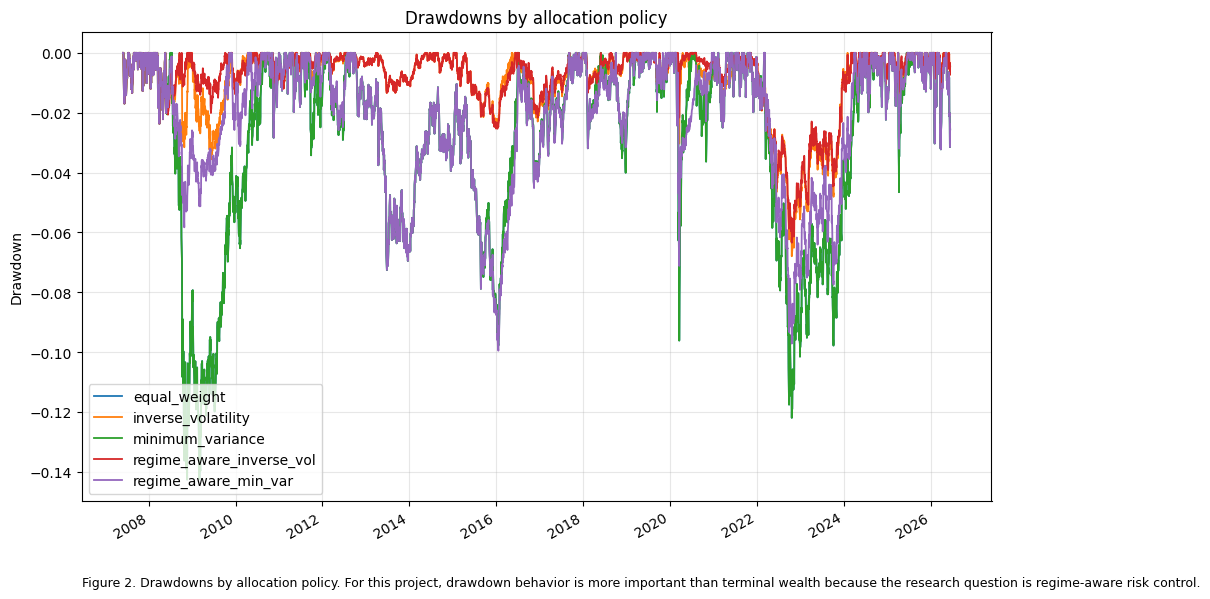

In [12]:
drawdowns = strategy_returns.apply(drawdown_series)

fig, ax = plt.subplots(figsize=(12, 6))

drawdowns.plot(ax=ax, linewidth=1.3)

ax.set_title("Drawdowns by allocation policy")
ax.set_ylabel("Drawdown")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")

caption = (
    "Figure 2. Drawdowns by allocation policy. "
    "For this project, drawdown behavior is more important than terminal wealth because the research question is regime-aware risk control."
)

ax.text(
    0.0,
    -0.16,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_drawdowns.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Visual diagnostic — summary risk metrics

This bar plot focuses on metrics aligned with the project narrative:

- annualized volatility,
- maximum drawdown,
- CVaR,
- average turnover.

The objective is to compare risk behavior, not to select a strategy purely by return.

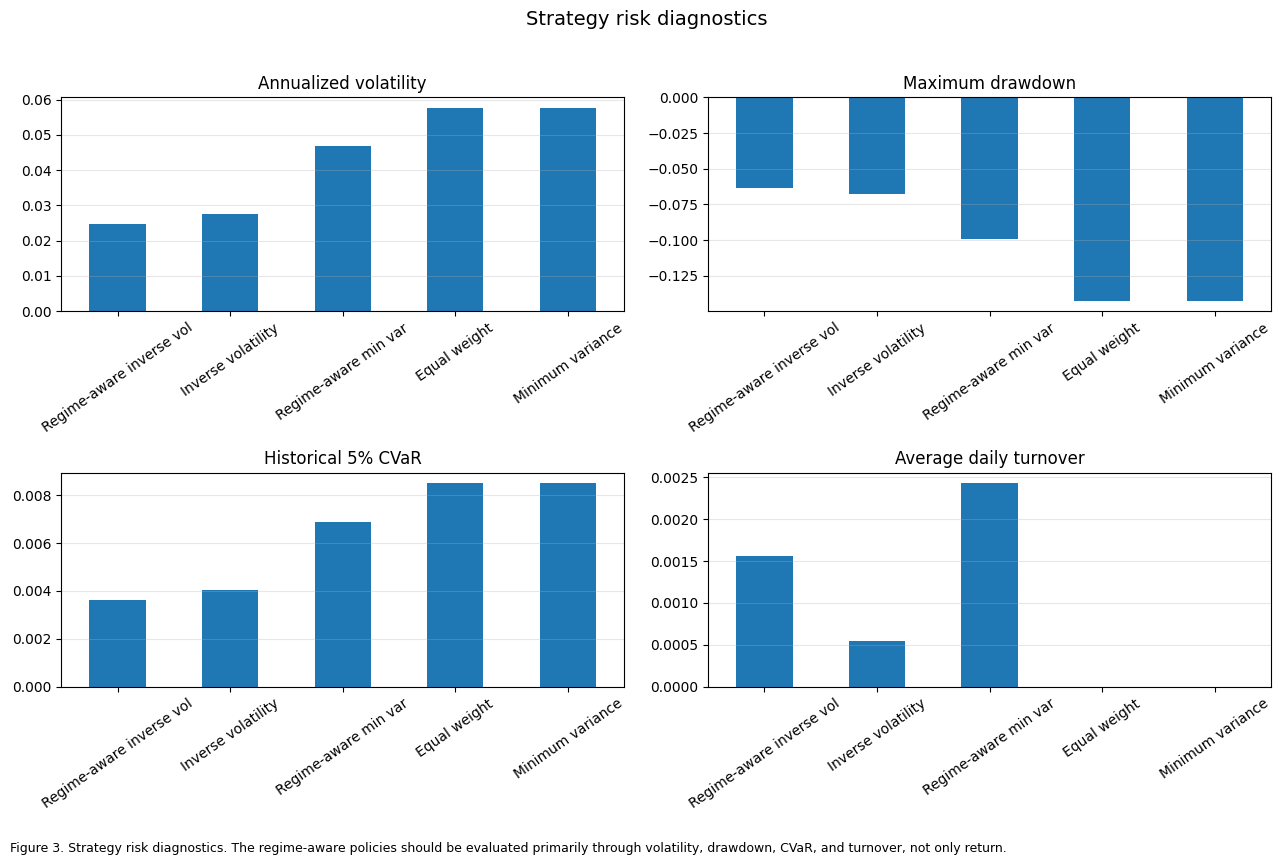

In [ ]:
summary_metrics = performance_summary[
    [
        "ann_vol",
        "max_drawdown",
        "cvar_5pct",
        "avg_daily_turnover",
    ]
].copy()

summary_metrics = summary_metrics.rename(index=strategy_display_names)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8.5))
axes = axes.ravel()

metric_titles = {
    "ann_vol": "Annualized volatility",
    "max_drawdown": "Maximum drawdown",
    "cvar_5pct": "Historical 5% CVaR",
    "avg_daily_turnover": "Average daily turnover",
}

for ax, metric in zip(axes, summary_metrics.columns):
    summary_metrics[metric].plot(kind="bar", ax=ax)
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Strategy risk diagnostics", y=1.02, fontsize=14)

caption = (
    "Figure 3. Strategy risk diagnostics. "
    "The regime-aware policies should be evaluated primarily through volatility, drawdown, CVaR, and turnover, not only return."
)

fig.subplots_adjust(bottom=0.28, hspace=0.55, wspace=0.25)

fig.text(
    0.01,
    0.02,
    caption,
    ha="left",
    va="bottom",
    fontsize=9,
    wrap=True,
)

fig.savefig(FIGURE_DIR / "04_strategy_risk_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 8.1 Regime-aware risk budget over time

The regime-aware policy works through a transparent risk-budget map.

This plot checks whether the allocation intensity changes as expected:

```text
regime 0 -> full risk budget
regime 1 -> partial de-risking
regime 2 -> strong de-risking

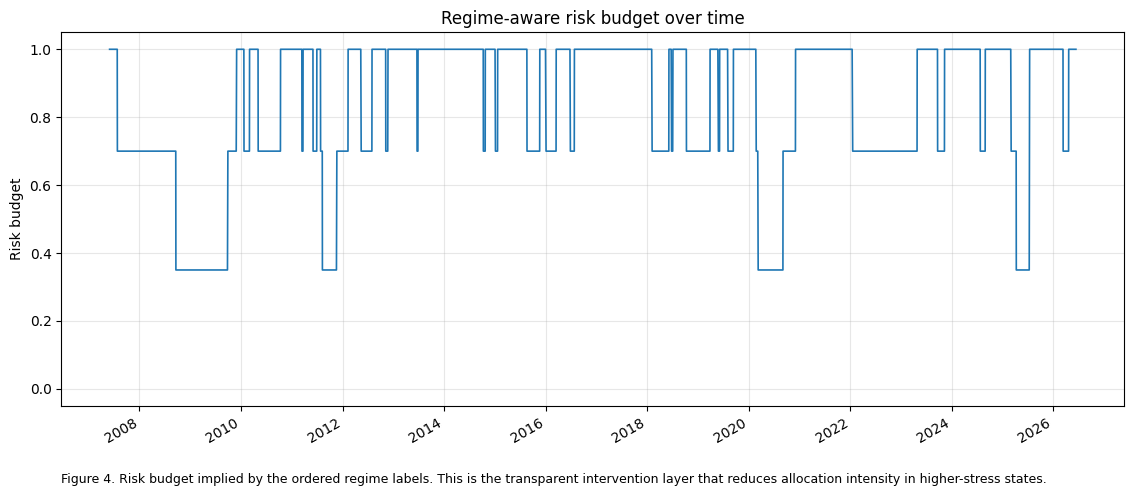

In [14]:
regime_budget_series = regimes_aligned.map(
    lambda regime: regime_risk_budget(int(regime), risk_budgets)
).rename("risk_budget")

fig, ax = plt.subplots(figsize=(12, 5))

regime_budget_series.plot(ax=ax, linewidth=1.2)

ax.set_title("Regime-aware risk budget over time")
ax.set_ylabel("Risk budget")
ax.set_xlabel("")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

caption = (
    "Figure 4. Risk budget implied by the ordered regime labels. "
    "This is the transparent intervention layer that reduces allocation intensity in higher-stress states."
)

ax.text(
    0.0,
    -0.18,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_regime_budget_series.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Visual diagnostic — regime-aware weights

This plot checks whether the regime-aware strategy behaves as designed.

In high-stress regimes, the defensive proxy `SHY` should absorb part of the risk budget.

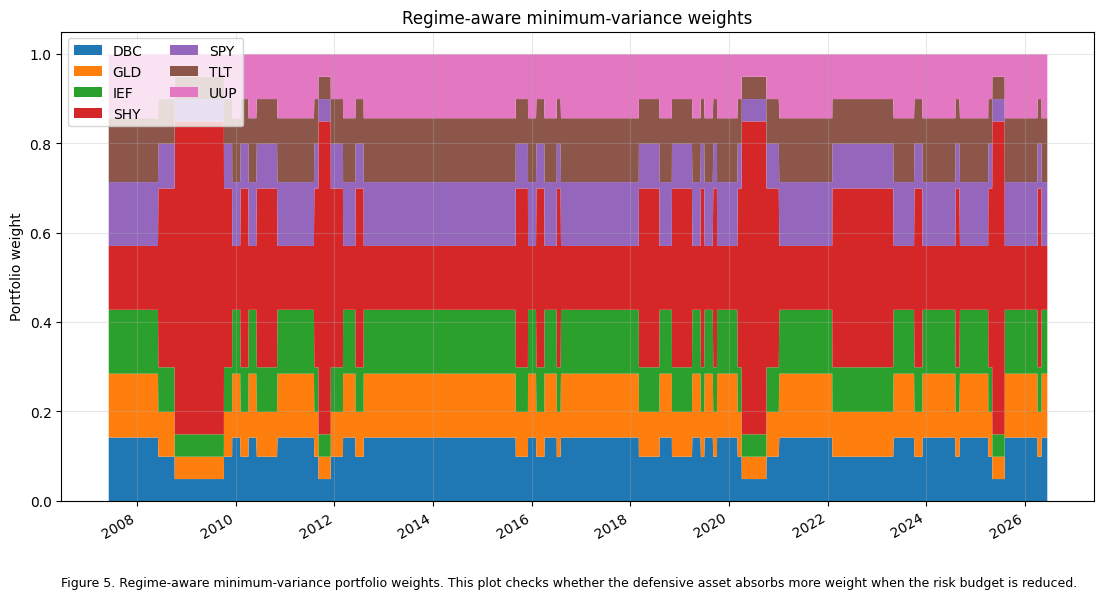

In [15]:
regime_aware_weights = results["regime_aware_min_var"].weights.copy()

fig, ax = plt.subplots(figsize=(12, 6))

regime_aware_weights.plot.area(ax=ax, linewidth=0.0)

ax.set_title("Regime-aware minimum-variance weights")
ax.set_ylabel("Portfolio weight")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", ncols=2)

caption = (
    "Figure 5. Regime-aware minimum-variance portfolio weights. "
    "This plot checks whether the defensive asset absorbs more weight when the risk budget is reduced."
)

ax.text(
    0.0,
    -0.16,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_regime_aware_weights.png", dpi=150, bbox_inches="tight")
plt.show()

## 9.1 Average allocation diagnostics

The area plot is useful visually, but average weights are easier to audit.

We report:

1. average weights by strategy;
2. average regime-aware minimum-variance weights by regime.

This helps verify that risk-budget reductions translate into actual defensive allocation changes.

In [16]:
average_weights_by_strategy = pd.concat(
    {name: result.weights.mean() for name, result in results.items()},
    axis=1,
).T

regime_aware_weight_data = regime_aware_weights.join(regimes_aligned.rename("regime"), how="inner")

average_weights_by_regime = (
    regime_aware_weight_data
    .groupby("regime")
    .mean()
)

print("Average weights by strategy")
display(average_weights_by_strategy)

print("Average regime-aware minimum-variance weights by regime")
display(average_weights_by_regime)

Average weights by strategy


,DBC,GLD,IEF,SHY,SPY,TLT,UUP
equal_weight,0.1429,0.1429,0.1429,0.1429,0.1429,0.1429,0.1429
inverse_volatility,0.0466,0.0513,0.1108,0.5887,0.0493,0.0551,0.0983
minimum_variance,0.1429,0.1429,0.1429,0.1429,0.1429,0.1429,0.1429
regime_aware_inverse_vol,0.0403,0.0437,0.0927,0.6511,0.0433,0.0463,0.0826
regime_aware_min_var,0.1216,0.1216,0.1216,0.2703,0.1216,0.1216,0.1216


Average regime-aware minimum-variance weights by regime


,DBC,GLD,IEF,SHY,SPY,TLT,UUP
regime,,,,,,,
0,0.1396,0.1396,0.1396,0.1625,0.1396,0.1396,0.1396
1,0.1121,0.1121,0.1121,0.3273,0.1121,0.1121,0.1121
2,0.0555,0.0555,0.0555,0.6671,0.0555,0.0555,0.0555


## 10. Export backtest outputs

The next notebook will reuse these outputs when comparing the SMDP-inspired stress-state policy.

In [17]:
strategy_returns.to_csv(DATA_DIR / "backtest_strategy_returns.csv")
performance_summary.to_csv(DATA_DIR / "backtest_performance_summary.csv")
allocation_regime_audit.to_frame().to_csv(DATA_DIR / "allocation_regime_audit.csv")
allocation_strategy_audit.to_csv(DATA_DIR / "allocation_strategy_audit.csv", index=False)
risk_reduction.to_csv(DATA_DIR / "allocation_risk_reduction.csv")
average_weights_by_strategy.to_csv(DATA_DIR / "allocation_average_weights_by_strategy.csv")
average_weights_by_regime.to_csv(DATA_DIR / "allocation_average_weights_by_regime.csv")

weights_long = []

for name, result in results.items():
    tmp = result.weights.copy()
    tmp["date"] = tmp.index
    tmp = tmp.melt(
        id_vars="date",
        var_name="asset",
        value_name="weight",
    )
    tmp["strategy"] = name
    weights_long.append(tmp)

weights_long = pd.concat(weights_long, ignore_index=True)
weights_long.to_csv(DATA_DIR / "backtest_weights_long.csv", index=False)

allocation_backtest_manifest = pd.DataFrame(
    [
        {
            "artifact": "backtest_strategy_returns.csv",
            "path": str(DATA_DIR / "backtest_strategy_returns.csv"),
            "rows": strategy_returns.shape[0],
            "columns": strategy_returns.shape[1],
            "purpose": "Daily net strategy returns from the walk-forward allocation backtest.",
        },
        {
            "artifact": "backtest_performance_summary.csv",
            "path": str(DATA_DIR / "backtest_performance_summary.csv"),
            "rows": performance_summary.shape[0],
            "columns": performance_summary.shape[1],
            "purpose": "Performance and risk diagnostics by strategy.",
        },
        {
            "artifact": "allocation_regime_audit.csv",
            "path": str(DATA_DIR / "allocation_regime_audit.csv"),
            "rows": allocation_regime_audit.shape[0],
            "columns": 1,
            "purpose": "Fail-fast validation of regime labels before allocation.",
        },
        {
            "artifact": "allocation_strategy_audit.csv",
            "path": str(DATA_DIR / "allocation_strategy_audit.csv"),
            "rows": allocation_strategy_audit.shape[0],
            "columns": allocation_strategy_audit.shape[1],
            "purpose": "Strategy behavior audit: turnover, terminal wealth, defensive exposure, and return differences.",
        },
        {
            "artifact": "allocation_risk_reduction.csv",
            "path": str(DATA_DIR / "allocation_risk_reduction.csv"),
            "rows": risk_reduction.shape[0],
            "columns": risk_reduction.shape[1],
            "purpose": "Risk reduction relative to equal weight.",
        },
        {
            "artifact": "allocation_average_weights_by_strategy.csv",
            "path": str(DATA_DIR / "allocation_average_weights_by_strategy.csv"),
            "rows": average_weights_by_strategy.shape[0],
            "columns": average_weights_by_strategy.shape[1],
            "purpose": "Average portfolio weights by strategy.",
        },
        {
            "artifact": "allocation_average_weights_by_regime.csv",
            "path": str(DATA_DIR / "allocation_average_weights_by_regime.csv"),
            "rows": average_weights_by_regime.shape[0],
            "columns": average_weights_by_regime.shape[1],
            "purpose": "Average regime-aware minimum-variance weights by regime.",
        },
        {
            "artifact": "backtest_weights_long.csv",
            "path": str(DATA_DIR / "backtest_weights_long.csv"),
            "rows": weights_long.shape[0],
            "columns": weights_long.shape[1],
            "purpose": "Long-format daily portfolio weights for all strategies.",
        },
    ]
)

allocation_backtest_manifest.to_csv(
    DATA_DIR / "allocation_backtest_manifest.csv",
    index=False,
)

print("Saved:")
print(DATA_DIR / "backtest_strategy_returns.csv")
print(DATA_DIR / "backtest_performance_summary.csv")
print(DATA_DIR / "allocation_regime_audit.csv")
print(DATA_DIR / "allocation_strategy_audit.csv")
print(DATA_DIR / "allocation_risk_reduction.csv")
print(DATA_DIR / "allocation_average_weights_by_strategy.csv")
print(DATA_DIR / "allocation_average_weights_by_regime.csv")
print(DATA_DIR / "backtest_weights_long.csv")
print(DATA_DIR / "allocation_backtest_manifest.csv")

display(allocation_backtest_manifest)

Saved:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/backtest_strategy_returns.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/backtest_performance_summary.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/allocation_regime_audit.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/allocation_strategy_audit.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/allocation_risk_reduction.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/allocation_average_weights_by_strategy.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/allocation_average_weights_by_regime.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/backtest_weights_long.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/allocation_backtest_manifest.csv


,artifact,path,rows,columns,purpose
0,backtest_strategy_returns.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4790,5,Daily net strategy returns from the walk-forwa...
1,backtest_performance_summary.csv,/workspaces/regime-aware-portfolio-risk-alloca...,5,13,Performance and risk diagnostics by strategy.
2,allocation_regime_audit.csv,/workspaces/regime-aware-portfolio-risk-alloca...,14,1,Fail-fast validation of regime labels before a...
3,allocation_strategy_audit.csv,/workspaces/regime-aware-portfolio-risk-alloca...,5,7,"Strategy behavior audit: turnover, terminal we..."
4,allocation_risk_reduction.csv,/workspaces/regime-aware-portfolio-risk-alloca...,5,3,Risk reduction relative to equal weight.
5,allocation_average_weights_by_strategy.csv,/workspaces/regime-aware-portfolio-risk-alloca...,5,7,Average portfolio weights by strategy.
6,allocation_average_weights_by_regime.csv,/workspaces/regime-aware-portfolio-risk-alloca...,3,7,Average regime-aware minimum-variance weights ...
7,backtest_weights_long.csv,/workspaces/regime-aware-portfolio-risk-alloca...,167650,4,Long-format daily portfolio weights for all st...


## 11. Notebook takeaway

This notebook compares transparent allocation baselines against regime-aware risk-budget policies.

Main outputs:

- regime-label audit before allocation,
- strategy behavior audit,
- walk-forward strategy returns,
- performance and risk summary,
- risk reduction relative to equal weight,
- turnover diagnostics,
- average weights by strategy,
- average regime-aware weights by regime.

Key interpretation:

1. The regime audit passes: all expected regimes are present before allocation.
2. The allocation audit prevents false comparisons by checking that strategies are numerically distinct.
3. Equal weight remains the simplest benchmark and should not be dismissed.
4. Inverse volatility is a robust risk-based benchmark and substantially reduces volatility and CVaR relative to equal weight.
5. The explicit regime-aware equal-weight policy isolates the effect of the risk-budget overlay.
6. Minimum variance must be interpreted only if the optimizer produces weights that are distinct from equal weight.
7. Regime-aware policies should be evaluated primarily by volatility, CVaR, drawdown, and turnover.
8. Lower drawdown or CVaR does not imply alpha. It supports the narrower claim that the regime variable can be useful for risk-budget control.
9. The SMDP-inspired notebook will build on this idea by treating regime/stress states as finite degradation states and allocation intensity as a control variable.

This notebook does not claim production readiness. It provides a transparent walk-forward experiment for regime-aware risk control.